# HW2 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [368]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from hw2_loader import HW2DataLoader
from model import GradientBoostingModel

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [369]:
# TODO: Load both datasets
loader = HW2DataLoader()

# Heart disease dataset
heart_path = Path('/Users/vanessaalexander/cs1851/homework-2-valexander21/homework2/data/heart.csv')
X_heart, y_heart = loader.get_heart_disease_data(csv_path=heart_path)
print(X_heart.shape, y_heart.value_counts().to_dict())

# Cancer genomics dataset
cancer_path = Path('/Users/vanessaalexander/cs1851/homework-2-valexander21/homework2/data/cancer_genomics.csv')
labels_path = Path('/Users/vanessaalexander/cs1851/homework-2-valexander21/homework2/data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(
    csv_path=cancer_path, labels_path=labels_path
)
print(X_cancer.shape, y_cancer.value_counts().to_dict())


Successfully loaded heart disease data with 1025 rows
(1025, 13) {1: 526, 0: 499}
(801, 5479) {'BRCA': 300, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136, 'COAD': 78}


Checking features and range of values

In [370]:
print('heart data features:', list(X_heart.keys()))
print('cancer data features:', list(X_cancer.keys()))
avg_max = []
avg_min = []
for i, c_class in enumerate(X_cancer.keys()):
    min_ = min(X_cancer[c_class])
    max_ = max(X_cancer[c_class])
    # if i % 100 == 0:
    #     print(f'{c_class}: min = {min_}, max = {max_}')
    avg_max.append(max_)
    avg_min.append(min_)
print(f'avg max: {np.mean(avg_max)}, max = {max(avg_max)}, min = {min(avg_max)}')
print(f'avg min: {np.mean(avg_min)}, min = {min(avg_min)}, max = {max(avg_min)}')
    

heart data features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
cancer data features: ['gene_18', 'gene_21', 'gene_26', 'gene_28', 'gene_29', 'gene_30', 'gene_31', 'gene_33', 'gene_39', 'gene_44', 'gene_45', 'gene_57', 'gene_58', 'gene_59', 'gene_61', 'gene_62', 'gene_63', 'gene_66', 'gene_67', 'gene_69', 'gene_71', 'gene_72', 'gene_75', 'gene_76', 'gene_77', 'gene_83', 'gene_84', 'gene_85', 'gene_87', 'gene_88', 'gene_89', 'gene_91', 'gene_92', 'gene_93', 'gene_94', 'gene_95', 'gene_97', 'gene_105', 'gene_111', 'gene_117', 'gene_126', 'gene_132', 'gene_133', 'gene_134', 'gene_145', 'gene_148', 'gene_153', 'gene_154', 'gene_163', 'gene_164', 'gene_165', 'gene_166', 'gene_172', 'gene_177', 'gene_180', 'gene_195', 'gene_197', 'gene_203', 'gene_216', 'gene_217', 'gene_218', 'gene_219', 'gene_220', 'gene_221', 'gene_223', 'gene_227', 'gene_228', 'gene_231', 'gene_233', 'gene_238', 'gene_241', 'gene_257', 'gene_263', 'gen

## Heart Dataset

### Init + train/test split + train/eval

In [371]:
# TODO: Initialize your model (adjust params)
model = GradientBoostingModel(
    task='classification',
    max_depth=3,
    learning_rate=0.1,
    n_estimators=50,
    use_scaler=False,
    random_state=42, 
    min_samples_leaf=1, 
    min_samples_split=2
)


In [372]:
# TODO: Train/test split + fit (heart)
X_train, X_test, y_train, y_test = model.train_test_split(X_heart, y_heart)
model.fit(X_train, y_train)
print(model.feature_names)


      Iter       Train Loss   Remaining Time 
         1           1.2784            0.40s
         2           1.1866            0.23s
         3           1.1129            0.17s
         4           1.0473            0.14s
         5           0.9846            0.13s
         6           0.9371            0.12s
         7           0.8898            0.11s
         8           0.8506            0.10s
         9           0.8135            0.09s
        10           0.7814            0.09s
        20           0.5716            0.05s
        30           0.4555            0.03s
        40           0.3883            0.02s
        50           0.3309            0.00s
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [373]:
# TODO: Evaluate (heart)
metrics = model.evaluate(X_test, y_test)
print(pd.Series(metrics))

accuracy     0.897561
precision    0.872727
recall       0.932039
f1           0.901408
roc_auc      0.968304
dtype: float64


In [374]:
# # TODO: Cross-validation (heart)
cv_results, summary = model.cross_validate(X_heart, y_heart)
df = pd.DataFrame(summary)
df_rename = df.rename(index={0: 'mean', 1: 'std'})

print("Heart Dataset cross validation")
print(pd.DataFrame(cv_results, index=np.arange(1, 6)))
print('--------------------------------------')
print('Avg Cross validation on full dataset')
print(df_rename)

accuracy


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
precision
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    3.0s remaining:    4.5s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.1s remaining:    0.2s


[CV] END .................................................... total time=   0.1s
recall
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.1s remaining:    0.1s


[CV] END .................................................... total time=   0.1s
f1
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
roc_auc


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
Heart Dataset cross validation
   accuracy  precision    recall        f1   roc_auc
1  0.960976   0.953271  0.971429  0.962264  0.994190
2  0.951220   0.935780  0.971429  0.953271  0.988857
3  0.936585   0.918182  0.961905  0.939535  0.967524
4  0.946341   0.935185  0.961905  0.948357  0.980190
5  0.941463   0.943396  0.943396  0.943396  0.976082
--------------------------------------
Avg Cross validation on full dataset
      accuracy  precision    recall        f1   roc_auc
mean  0.947317   0.937163  0.962013  0.949365  0.981369
std   0.008393   0.011528  0.010236  0.007936  0.009397


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished


     feature  feature_importance
2         cp            0.286104
11        ca            0.170406
12      thal            0.162773
9    oldpeak            0.116869
0        age            0.050962
7    thalach            0.046694
4       chol            0.045539
10     slope            0.042440
3   trestbps            0.030444
8      exang            0.021780
1        sex            0.021163
6    restecg            0.004827
5        fbs            0.000000


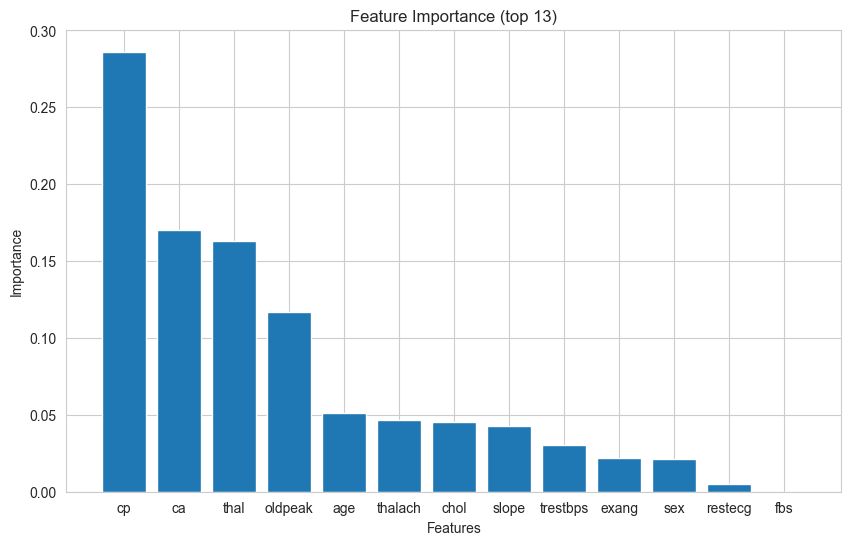

In [375]:
# TODO: Feature importance (heart)
feature_importance = model.get_feature_importance(plot=True, top_n=13)
print(feature_importance.head(13))


### Hyperparameter tuning

In [376]:
# TODO: Hyperparameter tuning (heart)
def tuning(X_train, y_train, param_grid, scoring):
    tuning_model = GradientBoostingModel(
        task='classification',
        max_depth=3,
        learning_rate=0.1,
        n_estimators=50,
        use_scaler=False,
        random_state=42, 
        min_samples_leaf=1, 
        min_samples_split=2
    )
    tuning_results = tuning_model.tune_hyperparameters(X_train, y_train, param_grid, cv=3, scoring=scoring)
    params = tuning_results['results']

    best_params = tuning_results['best_params']
    best_score = tuning_results['best_score']
    return params, best_params, best_score


In [377]:
param_grid = {
        'max_depth': [1, 2, 3, 4, 5],
        'n_estimators': [50, 100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1],
    }

params, best_params, best_score = tuning(X_train, y_train, param_grid, 'roc_auc')

Fitting 3 folds for each of 60 candidates, totalling 180 fits
[CV] END ...learning_rate=0.01, max_depth=1, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=1, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=1, n_estimators=50; total time=   0.0s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=200; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=500; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=500; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=1, n_e

In [378]:
df = pd.DataFrame(params)
df_res = df[['params', 'mean_test_score']]
pd.set_option('display.max_colwidth', None)
print(df_res.sort_values('mean_test_score', ascending=False).head(10))


                                                          params  \
59   {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500}   
39  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500}   
55   {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500}   
34  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}   
35  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500}   
58   {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}   
51   {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}   
37  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}   
19  {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500}   
38  {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}   

    mean_test_score  
59         0.997089  
39         0.994779  
55         0.994157  
34         0.994121  
35         0.993785  
58         0.993490  
51         0.991906  
37         0.991628  
19         0.991555  
38         0.991429  


In [379]:
lr = best_params['learning_rate']
m_d = best_params['max_depth']
n_est = best_params['n_estimators']

tuned_model = GradientBoostingModel(
    task='classification',
    max_depth=m_d,
    learning_rate=lr,
    n_estimators=n_est,
    use_scaler=False,
    random_state=42, 
    min_samples_leaf=1, 
    min_samples_split=2
)

tuned_model.fit(X_train, y_train, verbose=False)
metrics = tuned_model.evaluate(X_test, y_test)
print(f'Tuned model evaluation lr={lr}, max_depth={m_d}, n_estimators={n_est}')
print(pd.Series(metrics))


Tuned model evaluation lr=0.1, max_depth=5, n_estimators=500
accuracy     0.985366
precision    1.000000
recall       0.970874
f1           0.985222
roc_auc      1.000000
dtype: float64


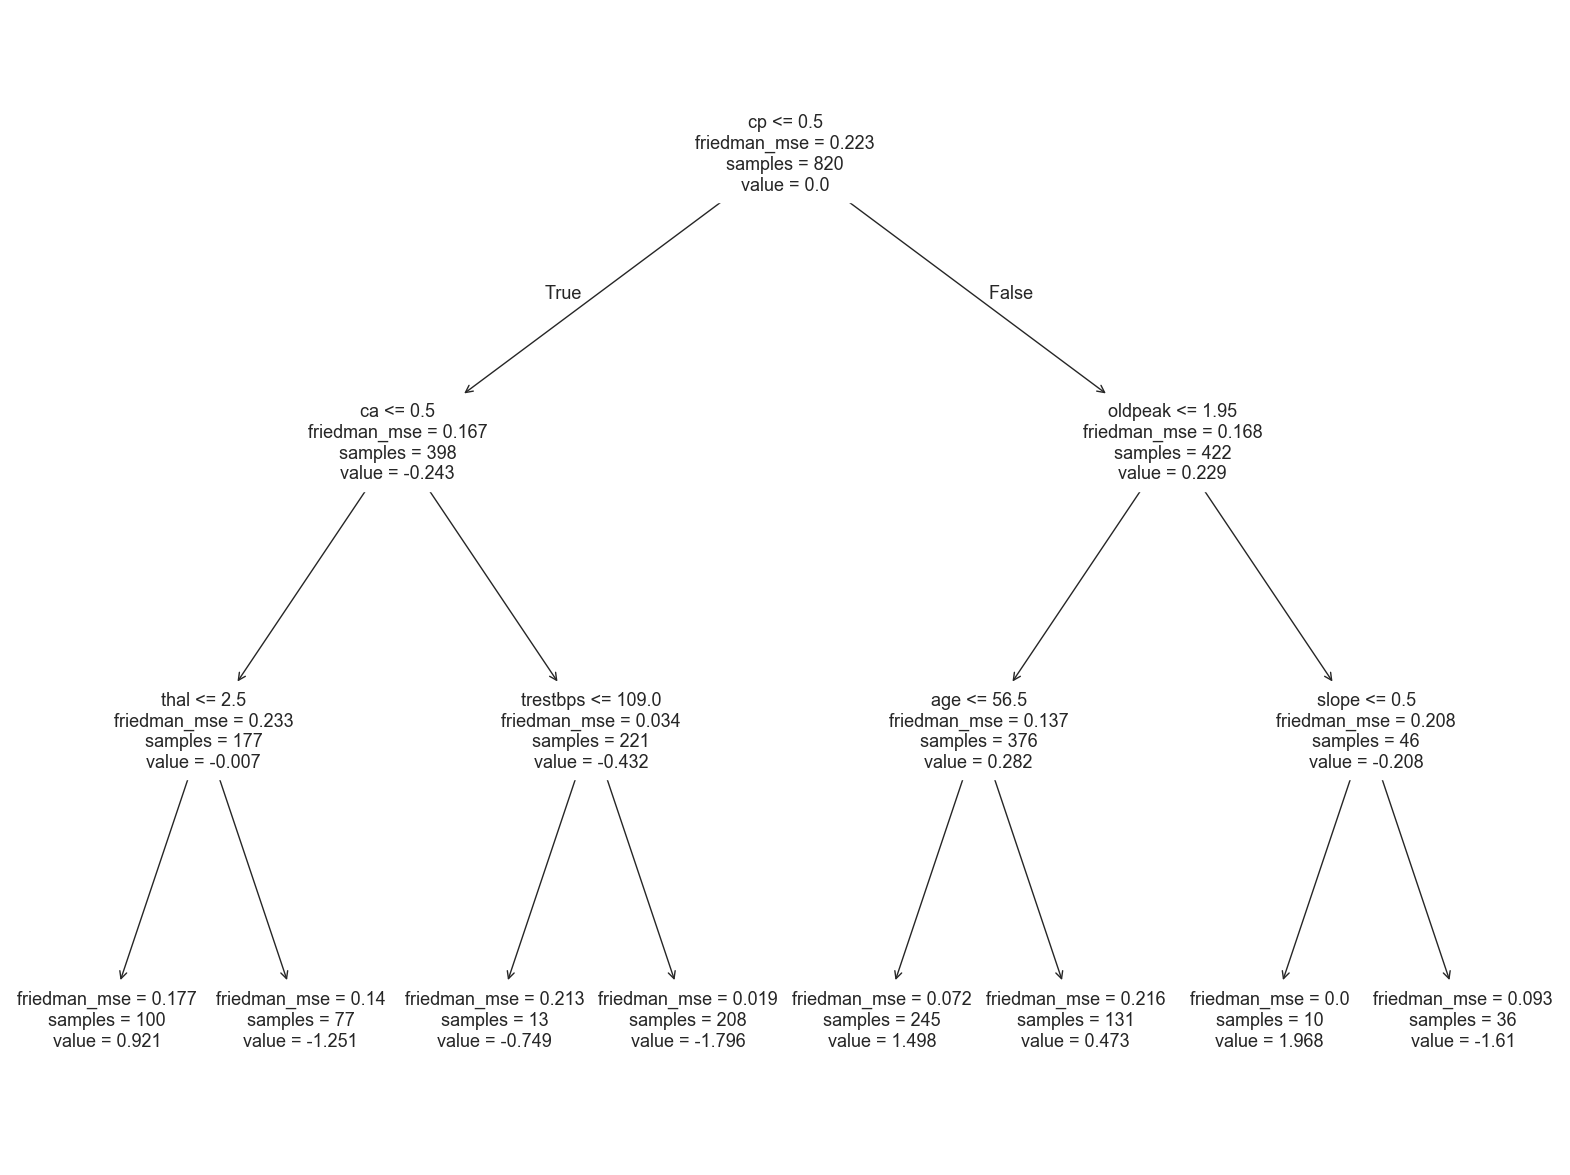

In [404]:
model.plot_tree(tree_index=1)


## Cancer Genomics Dataset

### Train/Eval

In [321]:
cancer_model = GradientBoostingModel(task='classification',
    max_depth=3,
    learning_rate=0.1,
    n_estimators=50,
    use_scaler=False,
    random_state=42, 
    min_samples_leaf=1, 
    min_samples_split=2)
X_train, X_test, y_train, y_test = cancer_model.train_test_split(X_cancer, y_cancer)

In [322]:
# TODO: Train/evaluate on cancer dataset (multi-class)

# fit
cancer_model.fit(X_train, y_train)
# evaluate 
metrics = cancer_model.evaluate(X_test, y_test)
# print metrics
print(pd.Series(metrics))

      Iter       Train Loss   Remaining Time 
         1           1.1337            3.21m
         2           0.9033            3.93m
         3           0.7357            4.11m
         4           0.6066            4.13m
         5           0.5041            4.10m
         6           0.4213            4.09m
         7           0.3535            4.02m
         8           0.2974            3.96m
         9           0.2509            3.87m
        10           0.2120            3.79m
        20           0.0413            2.88m
        30           0.0083            1.94m
        40           0.0017           57.98s
        50           0.0003            0.00s
accuracy     0.993789
precision    0.993889
recall       0.993789
f1           0.993760
roc_auc      0.999891
dtype: float64


In [315]:
cancer_model = GradientBoostingModel(task='classification',
    max_depth=1,
    learning_rate=0.1,
    n_estimators=50,
    use_scaler=False,
    random_state=42, 
    min_samples_leaf=1, 
    min_samples_split=2)

cv_results, summary = cancer_model.cross_validate(X_train, y_train)

df = pd.DataFrame(summary)
df_rename = df.rename(index={0: 'mean', 1: 'std'})

print("Cancer Genomic Train Dataset cross validation")
print(pd.DataFrame(cv_results, index=np.arange(1, 6)))
print('--------------------------------------')
print('Avg Cross validation on train dataset')
print(df_rename)

accuracy


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[CV] END .................................................... total time= 1.8min[CV] END .................................................... total time= 1.8min



[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.8min remaining:  2.7min


[CV] END .................................................... total time= 1.8min
[CV] END .................................................... total time= 1.8min
[CV] END .................................................... total time= 1.8min
precision_weighted


...

[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[CV] END .................................................... total time= 1.7min
[CV] END .................................................... total time= 1.7min


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.8min remaining:  2.6min


[CV] END .................................................... total time= 1.8min
[CV] END .................................................... total time= 1.8min
[CV] END .................................................... total time= 1.8min
Cancer Genomic Train Dataset cross validation
   accuracy  precision_weighted  recall_weighted  f1_weighted  roc_auc_ovr
1  0.960938            0.961606         0.960938     0.960526     0.999367
2  0.992188            0.992347         0.992188     0.992137     1.000000
3  0.992188            0.992488         0.992188     0.992173     0.999314
4  1.000000            1.000000         1.000000     1.000000     1.000000
5  1.000000            1.000000         1.000000     1.000000     1.000000
--------------------------------------
Avg Cross validation on train dataset
      accuracy  precision_weighted  recall_weighted  f1_weighted  roc_auc_ovr
mean  0.989062            0.989288         0.989062     0.988967     0.999736
std   0.014490            0.

[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.8min finished


### Feature Importance + Comparison to HW1

In [272]:
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression, Lasso

         feature  feature_importance
5167  gene_18746            0.289857
3674  gene_12983            0.202906


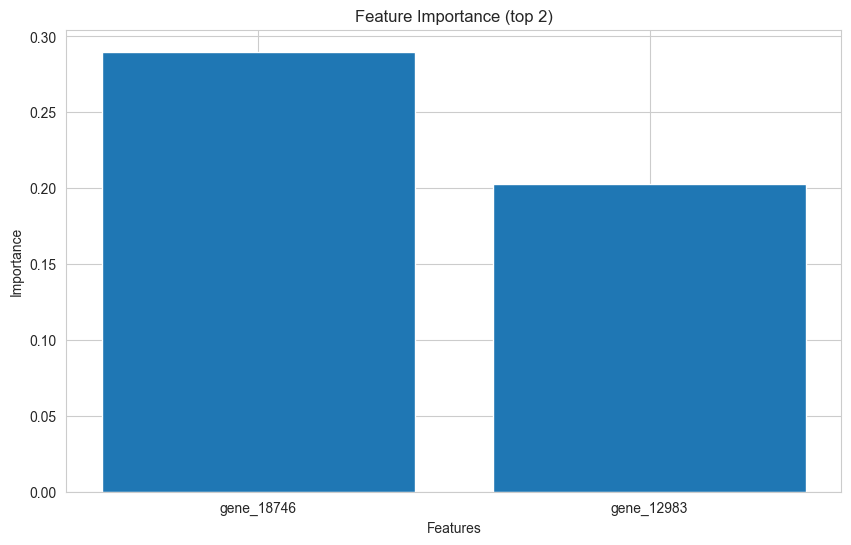

In [339]:
K = 2
feature_importance = cancer_model.get_feature_importance(plot=True, top_n=K)
print(feature_importance.head(K))

Train+Eval Entire Dataset

In [340]:
hw1_logreg = LogisticRegression(penalty='l2', C=1.0, random_state=42)
hw1_lasso = Lasso(alpha=1.0, random_state=42, max_iter=10000)

1.0


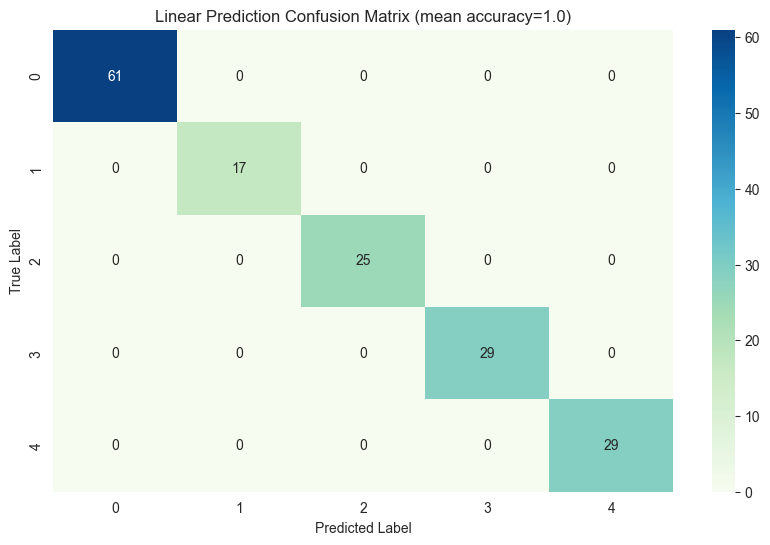

In [341]:
hw1_logreg.fit(X_train, y_train)
y_pred = hw1_logreg.predict(X_test)
score = hw1_logreg.score(X_test, y_test)
print(score)
cm = confusion_matrix(y_test, y_pred)
# print(cm)
sns.heatmap(cm, annot=True, cmap="GnBu")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Linear Prediction Confusion Matrix (mean accuracy={score})")
plt.savefig('../results/cancer/cm_fulldata')


Train+Eval Top-K Features

0.782608695652174
[[58  0  0  2  1]
 [ 0 11  0  6  0]
 [ 0  0 25  0  0]
 [ 0  4  0 14 11]
 [ 2  0  0  9 18]]


/Users/vanessaalexander/cs1851/homework-2-valexander21/homework2/.hw2/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


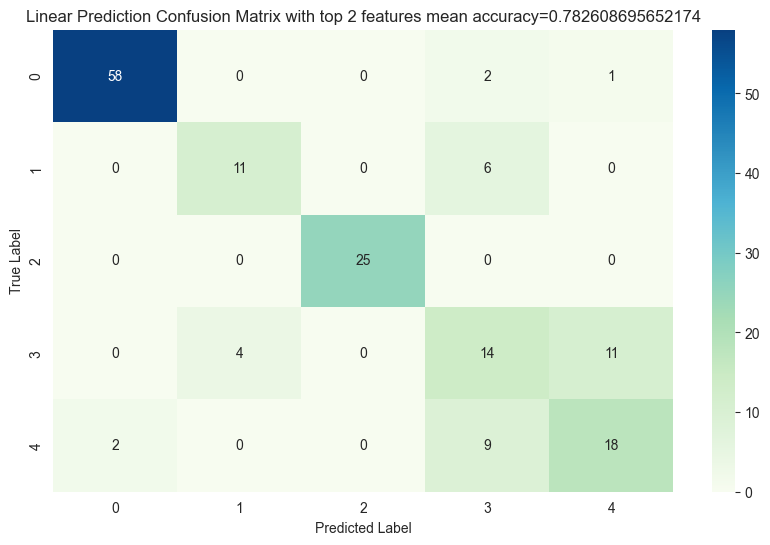

In [342]:
top_K_idx = list(feature_importance['feature'][:K])
X_ktrain, X_ktest = X_train.loc[:, top_K_idx], X_test.loc[:, top_K_idx]
# print(X_train.shape)
# print(y_train.shape)
top_k_model = LogisticRegression(penalty='l2', C=1.0, random_state=42)

top_k_model.fit(X_ktrain, y_train)
y_pred = top_k_model.predict(X_ktest)
score = top_k_model.score(X_ktest, y_test)
print(score)
cm = confusion_matrix(y_test, y_pred)

print(cm)
sns.heatmap(cm, annot=True, cmap="GnBu")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Linear Prediction Confusion Matrix with top {K} features mean accuracy={score}")
plt.savefig('../results/cancer/cm_topK_linear')


### Hyperparameter Tuning

In [209]:
param_grid = {
        'max_depth': [1, 3],
        'n_estimators': [50, 100]
    }

params, best_params, best_score = tuning(X_train, y_train, param_grid, 'f1_weighted')

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END .......................max_depth=1, n_estimators=50; total time= 1.1min
[CV] END .......................max_depth=1, n_estimators=50; total time= 1.1min
[CV] END .......................max_depth=1, n_estimators=50; total time= 1.1min
[CV] END ......................max_depth=1, n_estimators=100; total time= 2.2min
[CV] END ......................max_depth=1, n_estimators=100; total time= 2.2min
[CV] END ......................max_depth=1, n_estimators=100; total time= 2.2min
[CV] END .......................max_depth=3, n_estimators=50; total time= 3.1min
[CV] END .......................max_depth=3, n_estimators=50; total time= 3.1min
[CV] END .......................max_depth=3, n_estimators=50; total time= 3.0min
[CV] END ......................max_depth=3, n_estimators=100; total time= 5.6min
[CV] END ......................max_depth=3, n_estimators=100; total time= 3.7min
[CV] END ......................max_depth=3, n_est

In [210]:
df = pd.DataFrame(params)
df_res = df[['params', 'mean_test_score']]
pd.set_option('display.max_colwidth', None)
print(df_res.sort_values('mean_test_score', ascending=False).head(10))

                                  params  mean_test_score
0   {'max_depth': 1, 'n_estimators': 50}         0.993730
1  {'max_depth': 1, 'n_estimators': 100}         0.993725
2   {'max_depth': 3, 'n_estimators': 50}         0.990579
3  {'max_depth': 3, 'n_estimators': 100}         0.990579


In [212]:
# lr = best_params['learning_rate']
m_d = best_params['max_depth']
n_est = best_params['n_estimators']

tuned_model = GradientBoostingModel(
    task='classification',
    max_depth=m_d,
    learning_rate=0.1,
    n_estimators=n_est,
    use_scaler=False,
    random_state=42, 
    min_samples_leaf=1, 
    min_samples_split=2
)

tuned_model.fit(X_train, y_train, verbose=False)
metrics = tuned_model.evaluate(X_test, y_test)
print(f'Tuned model evaluation lr={lr}, max_depth={m_d}, n_estimators={n_est}')
print(pd.Series(metrics))

Tuned model evaluation lr=0.1, max_depth=1, n_estimators=50
accuracy     0.987578
precision    0.987679
recall       0.987578
f1           0.987503
roc_auc      0.999953
dtype: float64
